# Chapter 8 - Particle Phase-Space Coordinates

## Goals

This chapter introduces the six coordinates used by SciBmad to describe and track a particle.
By the end of the chapter, we will:

1. distinguish the lattice coordinate $s$ from the phase-space coordinate $z$;
2. interpret the normalized momenta $p_x$, $p_y$, and $p_z$;
3. construct a particle with a chosen initial phase-space state;
4. track that particle through a bend and quadrupole;
5. observe how changing one initial momentum coordinate changes the orbit.

In [ ]:
using Pkg
Pkg.activate(@__DIR__)
Pkg.instantiate()


In [4]:
using SciBmad
using CairoMakie
using Printf

## 8.1 The six-dimensional state

SciBmad stores one particle as

$$
\mathbf v=(x,\;p_x,\;y,\;p_y,\;z,\;p_z).
$$

The position-like coordinates are $x$, $y$, and $z$. The momentum-like coordinates are
$p_x$, $p_y$, and $p_z$. Together they specify the particle's initial state.

The coordinates have the following meanings:

| Coordinate | Meaning | Units |
|---|---|---|
| $x$ | horizontal offset from the reference trajectory | m |
| $p_x$ | normalized horizontal canonical momentum | dimensionless |
| $y$ | vertical offset from the reference trajectory | m |
| $p_y$ | normalized vertical canonical momentum | dimensionless |
| $z$ | longitudinal lead or lag relative to the reference particle | m |
| $p_z$ | relative total-momentum deviation | dimensionless |

The array order is important. A single-particle vector such as

```julia
[0.001, 0.002, 0.0, 0.0, 0.01, -0.02]
```

means $x=1\ \mathrm{mm}$, $p_x=0.002$, $z=1\ \mathrm{cm}$, and a total momentum
that is $2\%$ below the reference momentum.

## 8.2 Reference trajectory, reference particle, and reference momentum

The independent coordinate $s$ labels distance along the reference trajectory. At a chosen
$s$-location, $x$ and $y$ describe transverse displacement from that trajectory.

The phase-space coordinate $z$ is different from $s$. It records whether the tracked particle
arrives ahead of or behind the reference particle:

$$
t=t_{\mathrm{ref}}-\frac{z}{v}.
$$

Thus $z>0$ means the particle arrives early and is ahead; $z<0$ means it arrives late and is behind.

The reference particle's momentum $P_0$ is determined by the reference species and reference
total energy:

$$
P_0c=\sqrt{E_0^2-(mc^2)^2}.
$$

Although the reference particle is represented by the phase-space origin
$(0,0,0,0,0,0)$, it still carries the nonzero physical momentum $P_0$ along the reference
trajectory.

## 8.3 Momentum convention

The longitudinal phase-space momentum is

$$
p_z=\frac{P-P_0}{P_0},
\qquad
\frac{P}{P_0}=1+p_z,
$$

where $P$ is the **magnitude of the particle's total momentum**. Therefore, $p_z$ is not the
longitudinal component of momentum despite its name.

In a field-free region,

$$
p_x=\frac{P_x}{P_0},
\qquad
p_y=\frac{P_y}{P_0}.
$$

The normalized momentum component along the reference direction is then

$$
p_s=\sqrt{(1+p_z)^2-p_x^2-p_y^2}.
$$

Consequently, the horizontal slope in a drift is

$$
\frac{dx}{ds}=\frac{p_x}{p_s}.
$$

Only in the small-angle, nearly on-momentum limit is $x'\approx p_x$.

## 8.4 Example: track one off-axis, off-momentum particle

The original tutorial uses a bend followed by a quadrupole and starts a particle with

$$
y=0.01,\qquad p_x=0.06,\qquad p_z=-0.2,
$$

with all other phase-space coordinates zero.

To display a smooth orbit, the helper below represents each physical element by several short
tracking slices. This changes only the sampling resolution used for the plot.

In [5]:
species_ref = Species("electron")
E_ref = 1e9

function make_example_elements(; n_bend=50, n_quad=20)
    bend = [SBend(L=0.5 / n_bend, g_ref=1.0) for _ in 1:n_bend]
    quad = [Quadrupole(L=0.06 / n_quad, Kn1=10.0) for _ in 1:n_quad]
    return vcat(bend, quad)
end

function track_history(v0, elements; species_ref, E_ref)
    beamline = Beamline(elements; species_ref=species_ref, E_ref=E_ref)
    bunch = Bunch(copy(v0); species=beamline.species_ref, p_over_q_ref=beamline.p_over_q_ref)

    history = zeros(length(beamline.line) + 1, 6)
    history[1, :] .= bunch.coords.v[1, :]

    for (i, element) in enumerate(beamline.line)
        track!(bunch, element)
        history[i + 1, :] .= bunch.coords.v[1, :]
    end

    s = vcat(0.0, cumsum([element.L for element in beamline.line]))
    return (; s, history)
end

track_history (generic function with 1 method)

In [6]:
v_initial = [0.0, 0.06, 0.01, 0.0, 0.0, -0.2]
orbit_006 = track_history(
    v_initial,
    make_example_elements();
    species_ref=species_ref,
    E_ref=E_ref,
)

println("Initial coordinates: ", v_initial)
println("Final coordinates:   ", orbit_006.history[end, :])

Initial coordinates: [0.0, 0.06, 0.01, 0.0, 0.0, -0.2]
Final coordinates:   [0.220325403259328, 0.3118472698618971, 0.010252443098296328, 0.00605116192856123, -0.07940994587347927, -0.2]


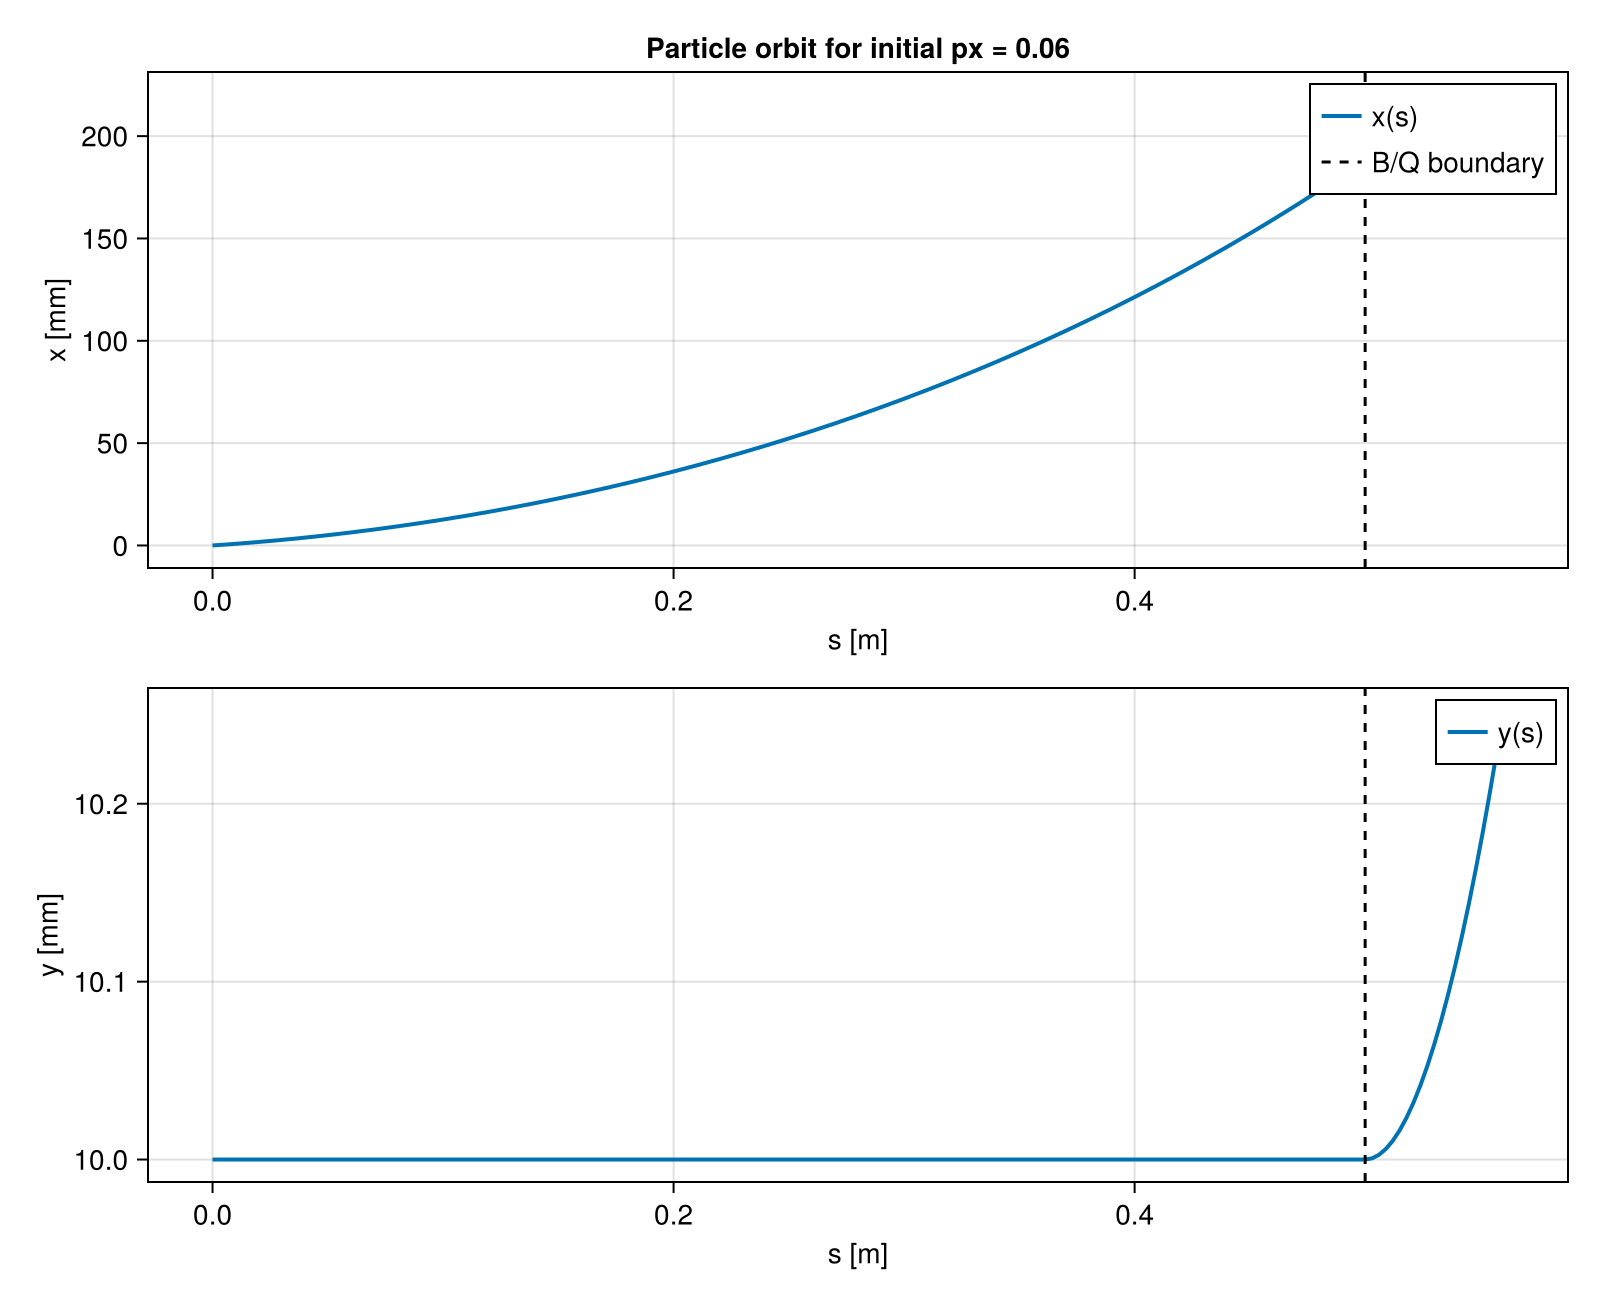

In [5]:
fig = Figure(size = (800, 650))

ax1 = Axis(fig[1, 1]; xlabel = "s [m]", ylabel = "x [mm]",
    title = "Particle orbit for initial px = 0.06")
lines!(ax1, orbit_006.s, 1e3 .* orbit_006.history[:, 1]; linewidth = 2, label = "x(s)")
vlines!(ax1, [0.5]; linestyle = :dash, color = :black, label = "B/Q boundary")
axislegend(ax1)

ax2 = Axis(fig[2, 1]; xlabel = "s [m]", ylabel = "y [mm]")
lines!(ax2, orbit_006.s, 1e3 .* orbit_006.history[:, 3]; linewidth = 2, label = "y(s)")
vlines!(ax2, [0.5]; linestyle = :dash, color = :black)
axislegend(ax2)

fig

The particle is not being given new properties during tracking. We selected a nonzero initial
phase-space point, and SciBmad propagated that state through the magnetic elements.

The bend changes the horizontal orbit strongly. The quadrupole couples position to momentum and
changes both transverse trajectories according to its focusing and defocusing action.

## 8.5 Change one initial momentum coordinate

Now change only $p_x$ from $0.06$ to $0.10$. This represents a different particle launched
from the same initial position and with the same total-momentum deviation.

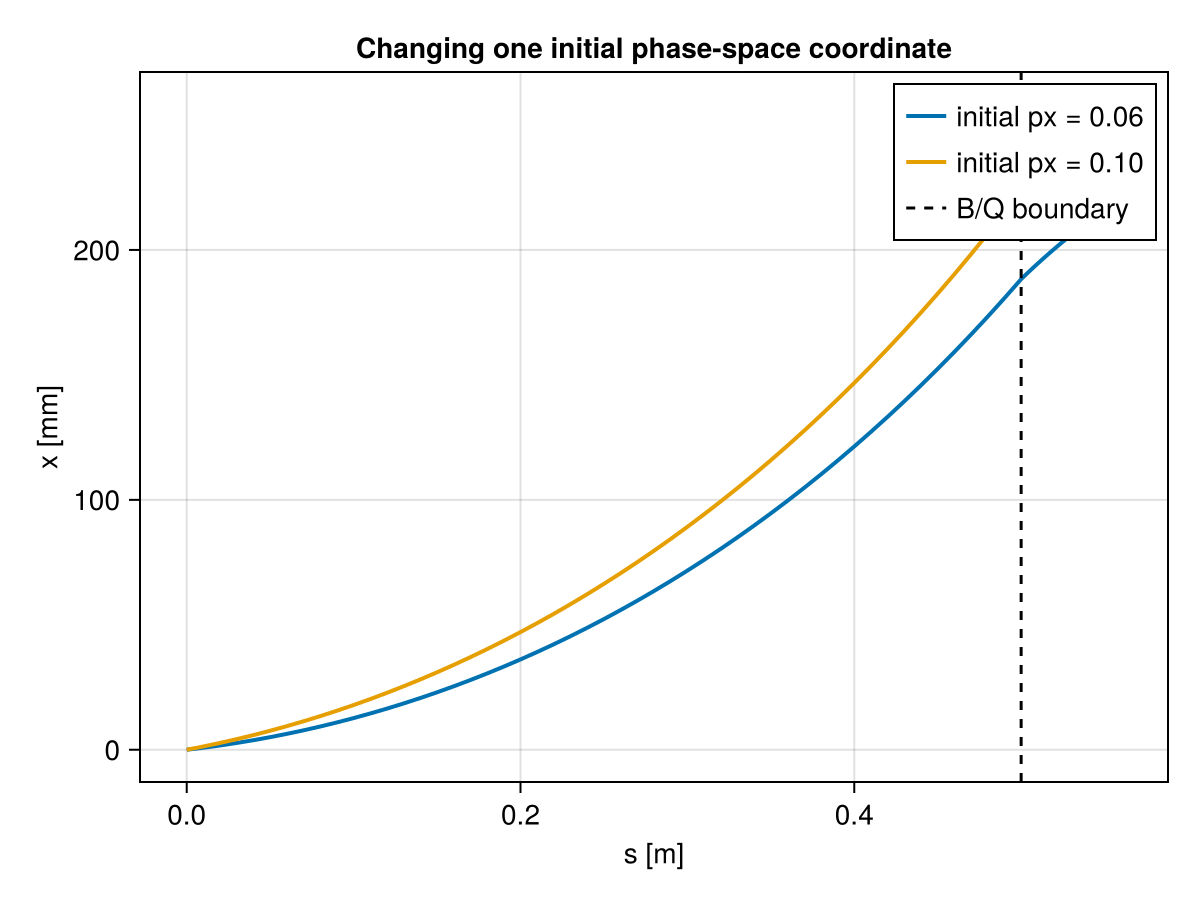

In [6]:
v_changed = [0.0, 0.10, 0.01, 0.0, 0.0, -0.2]
orbit_010 = track_history(
    v_changed,
    make_example_elements();
    species_ref=species_ref,
    E_ref=E_ref,
)

fig = Figure()
ax = Axis(fig[1, 1]; xlabel = "s [m]", ylabel = "x [mm]",
    title = "Changing one initial phase-space coordinate")
lines!(ax, orbit_006.s, 1e3 .* orbit_006.history[:, 1]; linewidth = 2, label = "initial px = 0.06")
lines!(ax, orbit_010.s, 1e3 .* orbit_010.history[:, 1]; linewidth = 2, label = "initial px = 0.10")
vlines!(ax, [0.5]; linestyle = :dash, color = :black, label = "B/Q boundary")
axislegend(ax)
fig

In [9]:
@printf("Final x for px = 0.06: %.6f m\n", orbit_006.history[end, 1])
@printf("Final x for px = 0.10: %.6f m\n", orbit_010.history[end, 1])
@printf("Difference:            %.6f m\n",
        orbit_010.history[end, 1] - orbit_006.history[end, 1])

Final x for px = 0.06: 0.220325 m
Final x for px = 0.10: 0.258303 m
Difference:            0.037977 m


## 8.6 Exercises

1. **Phase-space motion in a drift.**  
   Construct a beamline containing a single $2\ \mathrm{m}$ drift. Use protons with a reference total energy of $10^{12}\ \mathrm{eV}$, so the approximation that the particle velocity is the speed of light can be made. Set the initial particle coordinates to $(x,p_x,y,p_y,z,p_z)=(0,\;0.2,\;0,\;0,\;0,\;1)$.

   Calculate from first principles the phase-space coordinates at the end of the beamline, and check that the result agrees with SciBmad.
